In [1]:
import sys
from pathlib import Path

# 현재 노트북 기준으로 src 폴더 경로 추가
sys.path.append(str(Path("../src").resolve()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from constants import D_bg
from sigma_model import compute_sigma
from observables import compute_newtonian_acceleration, compute_rotation_velocity
from topological_gravity import compute_g_eff

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ---------------------------
# 테스트용 반지름 배열 생성
# 단위는 일단 SI로 가정 (m)
# ---------------------------

r = np.linspace(1.0e20, 2.0e21, 100)

# ---------------------------
# 테스트용 누적 질량 분포 M(r)
# 실제 데이터가 아니라 파이프라인 검증용 예시
# ---------------------------

M_r = 1.0e40 * (1.0 - np.exp(-r / 5.0e20))

# ---------------------------
# 테스트용 D_w 분포
# 바깥쪽으로 갈수록 약간 감소하는 구조를 가정
# ---------------------------

D_w = 3.2 - 0.2 * np.log10(r / r[0] + 1.0)

# 구조 대비 σ 계산
sigma = compute_sigma(D_w, D_bg)

In [5]:
g_N = compute_newtonian_acceleration(M_r, r)

In [6]:
# ---------------------------
# 구조 대비의 반지름 방향 기울기 계산
# np.gradient(y, x) 사용
# ---------------------------

sigma_gradient = np.gradient(sigma, r)

In [7]:
g_eff = compute_g_eff(g_N, sigma_gradient)

In [8]:
v_model = compute_rotation_velocity(g_eff, r)

In [9]:
print("r shape:", r.shape)
print("M_r shape:", M_r.shape)
print("D_w shape:", D_w.shape)
print("sigma shape:", sigma.shape)
print("sigma_gradient shape:", sigma_gradient.shape)
print("g_N shape:", g_N.shape)
print("g_eff shape:", g_eff.shape)
print("v_model shape:", v_model.shape)

r shape: (100,)
M_r shape: (100,)
D_w shape: (100,)
sigma shape: (100,)
sigma_gradient shape: (100,)
g_N shape: (100,)
g_eff shape: (100,)
v_model shape: (100,)


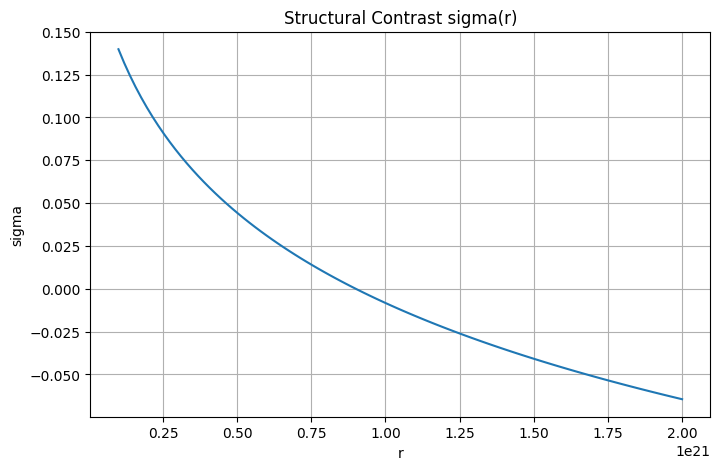

In [10]:
plt.figure(figsize=(8,5))
plt.plot(r, sigma)
plt.xlabel("r")
plt.ylabel("sigma")
plt.title("Structural Contrast sigma(r)")
plt.grid(True)
plt.show()

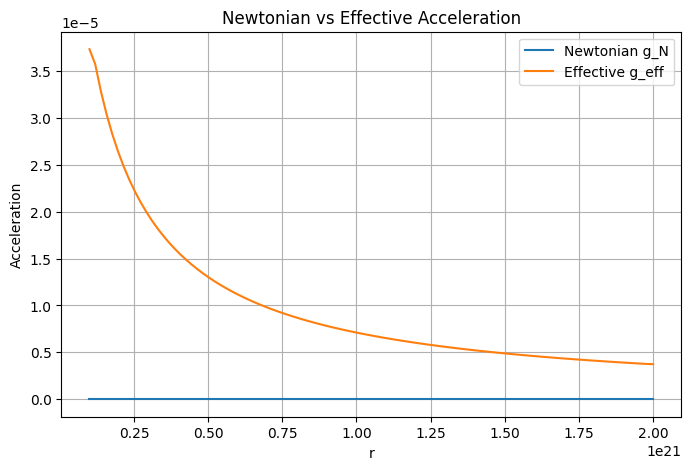

In [13]:
plt.figure(figsize=(8,5))
plt.plot(r, g_N, label="Newtonian g_N")
plt.plot(r, g_eff, label="Effective g_eff")
plt.xlabel("r")
plt.ylabel("Acceleration")
plt.title("Newtonian vs Effective Acceleration")
plt.legend()
plt.grid(True)
plt.show()

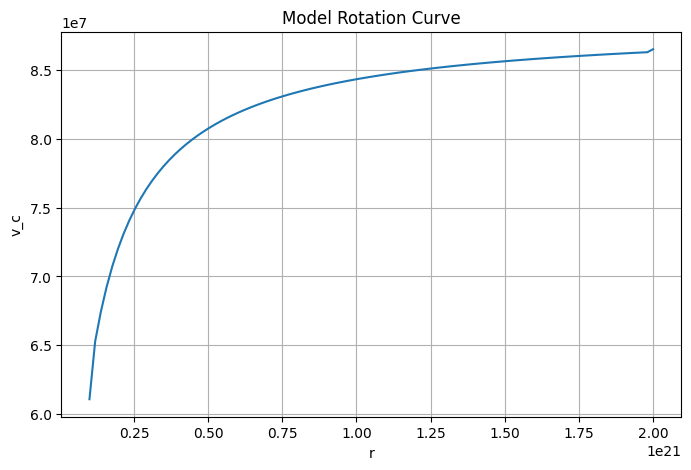

In [12]:
plt.figure(figsize=(8,5))
plt.plot(r, v_model)
plt.xlabel("r")
plt.ylabel("v_c")
plt.title("Model Rotation Curve")
plt.grid(True)
plt.show()